In [1]:
%%time
# =========================
# 0) Setup e imports - Competencia Final Data Mining UBA 2025
# =========================
!pip -q install polars==1.7.1 sympy matplotlib seaborn google-cloud-storage

import polars as pl
from pathlib import Path
from types import SimpleNamespace
import json, numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sympy import primerange
from google.cloud import storage

# Seeds oficiales de la competencia
SEEDS = [509963, 739373, 794341, 900623, 917827,
        946331, 682049, 415963, 163847, 846247,
        288203, 227407, 164513, 402299, 257437,
        789631, 812963, 361033, 698983, 827063,
        803591, 938053, 212791, 263759, 740023,
        426997, 507139, 185833, 929749, 412967,
        159473, 282571, 423853, 716707, 267133,
        895901, 115153, 173137, 228251, 568433,
        628937, 131591, 813961, 216421, 361327,
        759673, 105871, 484853, 239783, 724949,
]

# Paths definitivos en Google Cloud / repo git
NOTEBOOK_DIR = Path.cwd().resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parent.parent
SCHEMA_PATH = NOTEBOOK_DIR / "schema.json"
BASE_DIR    = NOTEBOOK_DIR / "dmeyf2025"

CPU times: user 5.11 s, sys: 471 ms, total: 5.58 s
Wall time: 5.27 s


In [2]:
# CSV_PATH    = PROJECT_ROOT / "datasets" / "competencia_02_crudo.csv"
# CSV_PATH2    = PROJECT_ROOT / "datasets" / "competencia_03_crudo.csv"
FINAL_PATH = PROJECT_ROOT / "datasets" / "competencia_03.csv"

# df1 = pd.read_csv(CSV_PATH)
# df2 = pd.read_csv(CSV_PATH2)
# df = pd.concat([df1, df2], ignore_index = True)
# df.to_csv(FINAL_PATH)


In [3]:
%%time
# =========================
# 1) Lectura de DF con Schema
# =========================

# Cargar schema
with open(SCHEMA_PATH) as f:
    schema_dict = json.load(f)

# Convertir strings a dtypes de Polars
schema = {k: getattr(pl, v) for k, v in schema_dict.items()}

# Lectura estricta (sin inferir tipos)
df = pl.read_csv(FINAL_PATH, schema_overrides=schema)
df = df.rechunk()  # Compactar memoria

first_col = df.columns[0]
df = df.drop(first_col)

df.shape

CPU times: user 57 s, sys: 19.7 s, total: 1min 16s
Wall time: 23.8 s


(4883051, 154)

In [4]:
# =========================
# 1.1) Canaritos + Setup de zLGBM
# =========================

def create_canaritos(df: pl.DataFrame, qcanaritos: int = 200) -> pl.DataFrame:
    """
    Añade un número específico de columnas "canarito" (features aleatorias)
    a un DataFrame de Polars.

    Estas nuevas columnas contendrán valores aleatorios uniformes (entre 0 y 1)
    y se colocarán al principio del DataFrame, manteniendo el orden
    original de las demás columnas.

    Args:
        df (pl.DataFrame): El DataFrame de Polars al que se le añadirán
                           las columnas.
        qcanaritos (int): El número de columnas "canarito" que se
                            desea crear (ej: 5).

    Returns:
        pl.DataFrame: Un nuevo DataFrame con las columnas "canarito" añadidas
                      al principio.
    """

    # 1. Guardar los nombres de las columnas originales
    original_cols = df.columns
    num_filas = df.height
    # 2. Generar la lista de nombres para las nuevas columnas "canarito"
    canary_cols = [f"canarito_{i}" for i in range(1, qcanaritos + 1)]

    # 3. Crear las expresiones Polars para generar los números aleatorios
    #    pl.rand_uniform(0, 1) es el equivalente a runif()
    canary_expressions = [pl.lit(np.random.rand(num_filas)).alias(name) for name in canary_cols]

    # 4. Añadir las nuevas columnas y reordenar todo en un solo paso
    #    Usamos .select() para el reordenamiento final
    df = df.with_columns(
        canary_expressions
    ).select(
        canary_cols + original_cols  # Concatena listas para el nuevo orden
    )

    return df

In [5]:
%%time
# =========================
# 2) Construcción de clase_ternaria (baseline del profesor)
# =========================

def agregar_clase_ternaria_optimizada(df: pl.DataFrame) -> pl.DataFrame:
    """
    Versión optimizada usando Polars - Baseline del profesor
    """
    return (
        df.lazy()
        .sort(["numero_de_cliente", "foto_mes"])
        .with_columns([
            pl.when(
                pl.col("foto_mes").shift(-1).over("numero_de_cliente").is_null() &
                (pl.col("foto_mes") != pl.col("foto_mes").max())
            ).then(pl.lit("BAJA+1"))
            .when(
                pl.col("foto_mes").shift(-2).over("numero_de_cliente").is_null() &
                (pl.col("foto_mes") <= pl.col("foto_mes").max() - 2)
            ).then(pl.lit("BAJA+2"))
            .otherwise(pl.lit("CONTINUA"))
            .alias("clase_ternaria")
        ])
        .collect()
    )

# Agregar la columna clase_ternaria
df = agregar_clase_ternaria_optimizada(df)

# Tabla de frecuencia de clase_ternaria por foto_mes
tabla_clases = (
    df.pivot(
        values="numero_de_cliente",
        index="foto_mes",
        on="clase_ternaria",
        aggregate_function="len"
    )
    .fill_null(0)
)

print(tabla_clases)

shape: (33, 4)
┌──────────┬──────────┬────────┬────────┐
│ foto_mes ┆ CONTINUA ┆ BAJA+2 ┆ BAJA+1 │
│ ---      ┆ ---      ┆ ---    ┆ ---    │
│ i64      ┆ u32      ┆ u32    ┆ u32    │
╞══════════╪══════════╪════════╪════════╡
│ 201901   ┆ 122920   ┆ 720    ┆ 633    │
│ 201902   ┆ 123985   ┆ 694    ┆ 722    │
│ 201903   ┆ 124535   ┆ 738    ┆ 694    │
│ 201904   ┆ 125294   ┆ 501    ┆ 743    │
│ 201905   ┆ 126016   ┆ 682    ┆ 504    │
│ …        ┆ …        ┆ …      ┆ …      │
│ 202105   ┆ 161948   ┆ 841    ┆ 1128   │
│ 202106   ┆ 162339   ┆ 1133   ┆ 841    │
│ 202107   ┆ 162211   ┆ 1250   ┆ 1135   │
│ 202108   ┆ 163570   ┆ 0      ┆ 1252   │
│ 202109   ┆ 165093   ┆ 0      ┆ 0      │
└──────────┴──────────┴────────┴────────┘
CPU times: user 11.5 s, sys: 7.11 s, total: 18.6 s
Wall time: 4 s


In [6]:
# =========================
# Feature engineering: agregados de montos/contadores
# =========================

# Totales de saldos en pesos
SALDOS_PESOS = [
    "mcuenta_corriente",
    "mcaja_ahorro",
    "mcuenta_corriente_adicional",
    "mcaja_ahorro_adicional",
    "mcuentas_saldo",
]

# Consumo tarjetas pesos
CONSUMO_TARJETAS_PESOS = [
    "mtarjeta_visa_consumo",
    "mtarjeta_master_consumo",
]

# Consumo tarjetas dólares
CONSUMO_TARJETAS_DOLARES = [
    "Visa_mconsumosdolares",
    "Master_mconsumosdolares",
]

# Pagos recurrentes pesos
PAGOS_RECURRENTE_PESOS = [
    "mpagodeservicios",
    "mpagomiscuentas",
    "mcuenta_debitos_automaticos",
    "mttarjeta_visa_debitos_automaticos",
    "mttarjeta_master_debitos_automaticos",
]

# Sumas de productos de inversión y plazos fijos pesos
INVERSIONES_PESOS = [
    "mplazo_fijo_pesos",
    "minversion1_pesos",
    "minversion2",
]

# Sumas de productos de inversión y plazos fijos dólares
INVERSIONES_DOLARES = [
    "mplazo_fijo_dolares",
    "minversion1_dolares",
]

# Endeudamiento total pesos
ENDEUDAMIENTO_PESOS = [
    "mprestamos_prendarios",
    "mprestamos_hipotecarios",
    "Master_msaldopesos",
    "Visa_msaldopesos",
    "Master_madelantopesos",
    "Visa_madelantopesos",
]

# Endeudamiento total dólares
ENDEUDAMIENTO_DOLARES = [
    "Master_msaldodolares",
    "Visa_msaldodolares",
    "Master_madelantodolares",
    "Visa_madelantodolares",
]

# Ingresos payroll pesos
PAYROLL_PESOS = [
    "mpayroll",
    "mpayroll2",
]

# Límites de compra
LIMITES_COMPRA = [
    "Master_mlimitecompra",
    "Visa_mlimitecompra",
]

# Suma de seguros contratados
SEGUROS_COUNT = [
    "cseguro_vida",
    "cseguro_auto",
    "cseguro_vivienda",
    "cseguro_accidentes_personales",
]

# Totales de transacciones (conteo)
TRANSACCIONES_COUNT = [
    "ctarjeta_debito_transacciones",
    "ctarjeta_visa_transacciones",
    "ctarjeta_master_transacciones",
    "chomebanking_transacciones",
    "cmobile_app_trx",
    "ccallcenter_transacciones",
    "catm_trx",
    "catm_trx_other",
    "ccajas_transacciones",
]

def sum_columns_safe(df: pl.DataFrame, cols: list[str]) -> pl.Series:
    existentes = [c for c in cols if c in df.columns]
    if not existentes:
        return pl.lit(0)
    return pl.sum_horizontal([pl.col(c) for c in existentes])

fe_columns = {
    "m_saldo_total_pesos": SALDOS_PESOS,
    "m_consumo_tarjetas_pesos": CONSUMO_TARJETAS_PESOS,
    "m_consumo_tarjetas_dolares": CONSUMO_TARJETAS_DOLARES,
    "m_pagos_recurrentes_pesos": PAGOS_RECURRENTE_PESOS,
    "m_inversiones_pesos": INVERSIONES_PESOS,
    "m_inversiones_dolares": INVERSIONES_DOLARES,
    "m_endeudamiento_pesos": ENDEUDAMIENTO_PESOS,
    "m_endeudamiento_dolares": ENDEUDAMIENTO_DOLARES,
    "m_payroll_total": PAYROLL_PESOS,
    "m_limite_compra_total": LIMITES_COMPRA,
    "c_seguros_total": SEGUROS_COUNT,
    "c_transacciones_total": TRANSACCIONES_COUNT,
}

df = df.with_columns([
    sum_columns_safe(df, cols).alias(col_name)
    for col_name, cols in fe_columns.items()
])

df.shape

(4883051, 167)

In [7]:
%%time
# =========================
# 4) Feature Engineering Histórico - Lags y DeltaLags
# =========================

# Excluir IDs y metadata
EXCLUDE = {"numero_de_cliente", "foto_mes", "clase_ternaria"}

# Identificar columnas numéricas
num_cols = [c for c, dt in zip(df.columns, df.dtypes)
            if c not in EXCLUDE and dt.is_numeric()]

def add_lags_and_deltas(df: pl.DataFrame, cols: list[str]) -> pl.DataFrame:
    """
    Agregar lags y deltas de orden 1 y 2 - Baseline del profesor
    """
    out = df.sort(["numero_de_cliente", "foto_mes"]).lazy()

    # Lags 1 y 2
    out = out.with_columns([
        pl.col(c).shift(1).over("numero_de_cliente").alias(f"{c}_lag1") for c in cols
    ] + [
        pl.col(c).shift(2).over("numero_de_cliente").alias(f"{c}_lag2") for c in cols
    ])

    # Delta 1: x_t - x_{t-1} ; Delta 2: x_t - x_{t-2}
    out = out.with_columns([
        (pl.col(c) - pl.col(f"{c}_lag1")).alias(f"{c}_d1") for c in cols
    ] + [
        (pl.col(c) - pl.col(f"{c}_lag2")).alias(f"{c}_d2") for c in cols
    ])

    return out.collect()

# Aplicar lags y deltas
df = add_lags_and_deltas(df, num_cols)

df.shape

CPU times: user 2min 23s, sys: 49.7 s, total: 3min 13s
Wall time: 2min 44s


(4883051, 823)

In [8]:
# =========================
# 4.1) Creacion de Canaritos
# =========================

plocal = SimpleNamespace(
    qcanaritos=200,
    min_data_in_leaf=500,
    learning_rate=5.0,
    gradient_bound=8,
    ksemillerio=50,
)

df = create_canaritos(df, plocal.qcanaritos)

In [9]:
# Configuración de la competencia
TRAIN_MESES = [
    201901, 201902, 201903, #201904, 
    201905, 201906, 201907, 201908, 
    201909, 201910, 201911, 201912, 
    202001, 202002, 202003, 202004, 202005, #202006, 
    202007, 202008, 202009, #202010, 
    202011, 202012, 202101, 202102,
    202103, 202104, 202105, 202106,
    202107
]

#TEST_MES   = 202107
#TEST_MES2   = 202107

APPLY_MES = 202109


In [10]:
%%time
# =========================
# 5) Undersampling de todos los registros CONTINUA al 3%
# =========================

train_subset = df.filter(pl.col("foto_mes").is_in(TRAIN_MESES))

# Separar registros por clase
registros_continua = train_subset.filter(pl.col("clase_ternaria") == "CONTINUA")
registros_baja = train_subset.filter(pl.col("clase_ternaria").is_in(["BAJA+1", "BAJA+2"]))

# Hacer undersampling del 3% de todos los registros CONTINUA
fraccion_sample = 0.15
n_total_continua = registros_continua.height
n_sample = max(1, int(np.ceil(n_total_continua * fraccion_sample)))

registros_continua_sample = registros_continua.sample(n=n_sample, seed=SEEDS[0])

# Combinar registros CONTINUA muestreados con todos los BAJA
_df_train = pl.concat([registros_continua_sample, registros_baja])
#_df_test = df.filter(pl.col("foto_mes") == TEST_MES)
_df_apply = df.filter(pl.col("foto_mes") == APPLY_MES)

CPU times: user 1min 44s, sys: 1min 40s, total: 3min 25s
Wall time: 26.6 s


In [11]:
# =========================
# 5.1) Validación de la data
# =========================

print("_df_train shape:", _df_train.shape)
#print("_df_test shape:", _df_test.shape)
print("_df_apply shape:", _df_apply.shape)
print("Primeras columnas en df      :", df.columns[:10])
print("Primeras columnas en _df_train:", _df_train.columns[:10])

_df_train shape: (649054, 1023)
_df_apply shape: (165093, 1023)
Primeras columnas en df      : ['canarito_1', 'canarito_2', 'canarito_3', 'canarito_4', 'canarito_5', 'canarito_6', 'canarito_7', 'canarito_8', 'canarito_9', 'canarito_10']
Primeras columnas en _df_train: ['canarito_1', 'canarito_2', 'canarito_3', 'canarito_4', 'canarito_5', 'canarito_6', 'canarito_7', 'canarito_8', 'canarito_9', 'canarito_10']


In [12]:
%%time
# =========================
# 6) Entrenamiento LightGBM con métrica de ganancia (semillero)
# =========================

plocal = SimpleNamespace(
    qcanaritos=200,
    min_data_in_leaf=500,
    learning_rate=5.0,
    gradient_bound=8,
    ksemillerio=50,  
)

PARAM = SimpleNamespace(
    semilla_primigenia=SEEDS[0],  
    qcanaritos=plocal.qcanaritos,
)

# Constantes de ganancia
GANANCIA_ACIERTO = 780000
COSTO_ESTIMULO = 20000

def calcular_ganancias_acumuladas(y_true, y_pred_proba):
    """Calcula la ganancia acumulada ordenando por probabilidad descendente."""
    df_eval = pl.DataFrame({"y_true": y_true, "y_pred_proba": y_pred_proba})
    df_ordenado = df_eval.sort("y_pred_proba", descending=True)
    df_ordenado = df_ordenado.with_columns(
        pl.when(pl.col("y_true") == 1)
        .then(GANANCIA_ACIERTO)
        .otherwise(-COSTO_ESTIMULO)
        .alias("ganancia_individual")
    )
    df_ordenado = df_ordenado.with_columns(
        pl.col("ganancia_individual").cast(pl.Int64).cum_sum().alias("ganancia_acumulada")
    )
    return df_ordenado["ganancia_acumulada"].to_numpy()

# Convertir a pandas
train_pd = _df_train.to_pandas()
#test_pd = _df_test.to_pandas()
apply_df = _df_apply.to_pandas()

drop_cols = {"numero_de_cliente", "foto_mes", "clase_ternaria"}
feature_cols = [c for c in train_pd.columns if c not in drop_cols]

print("=== Dataset shapes ===")
#print(f"train: {train_pd.shape} | test: {test_pd.shape}")
print(f"Features disponibles: {len(feature_cols)} (incluye canaritos={plocal.qcanaritos})")

# Targets y pesos
y_train = train_pd["clase_ternaria"].isin(["BAJA+1", "BAJA+2"]).astype(int)

weight_train = np.where(y_train == 1, 1.00002, 1.0)

lgb_train = lgb.Dataset(train_pd[feature_cols], label=y_train, weight=weight_train)

print("\n=== Configuración del semillero ===")
print(f"semilla_primigenia={PARAM.semilla_primigenia}")
print(f"qcanaritos={PARAM.qcanaritos}")
print(f"ksemillerio={plocal.ksemillerio}")

print("\n=== Comenzando entrenamiento del semillero ===")

models = []
predictions_per_seed = []

for i, seed in enumerate(SEEDS[:plocal.ksemillerio], start=1):
    print(f"\n[Seed {i}/{plocal.ksemillerio}] Entrenando modelo con seed={seed} ...")

    lgbm_param_completo = {
        "boosting": "gbdt",
        "objective": "binary",
        "metric": "None",
        "first_metric_only": False,
        "boost_from_average": True,
        "feature_pre_filter": False,
        "force_row_wise": True,
        "verbosity": -100,
        "seed": int(seed),
        "max_bin": 31,
        "min_data_in_leaf": plocal.min_data_in_leaf,
        "num_leaves": 9999,
        "learning_rate": plocal.learning_rate,
        "feature_fraction": 0.50,
        "canaritos": PARAM.qcanaritos,
        "gradient_bound": plocal.gradient_bound,
        "num_iterations": 33,
    }

    print(
        f"  -> Parámetros: seed={lgbm_param_completo['seed']}, "
        f"min_leaf={plocal.min_data_in_leaf}, lr={plocal.learning_rate}, "
        f"num_leaves={lgbm_param_completo['num_leaves']}, "
        f"feature_fraction={lgbm_param_completo['feature_fraction']}"
    )

    model = lgb.train(
        lgbm_param_completo,
        train_set=lgb_train,
    )

     # Guardar modelo
    models.append(model)

    apply_pred = model.predict(apply_df[feature_cols])

    predictions_per_seed.append(apply_pred)

    # Predicción en test
    #valid_scores = model.predict(test_pd[feature_cols], num_iteration=best_iteration)

=== Dataset shapes ===
Features disponibles: 1020 (incluye canaritos=200)

=== Configuración del semillero ===
semilla_primigenia=509963
qcanaritos=200
ksemillerio=50

=== Comenzando entrenamiento del semillero ===

[Seed 1/50] Entrenando modelo con seed=509963 ...
  -> Parámetros: seed=509963, min_leaf=500, lr=5.0, num_leaves=9999, feature_fraction=0.5

[Seed 2/50] Entrenando modelo con seed=739373 ...
  -> Parámetros: seed=739373, min_leaf=500, lr=5.0, num_leaves=9999, feature_fraction=0.5

[Seed 3/50] Entrenando modelo con seed=794341 ...
  -> Parámetros: seed=794341, min_leaf=500, lr=5.0, num_leaves=9999, feature_fraction=0.5

[Seed 4/50] Entrenando modelo con seed=900623 ...
  -> Parámetros: seed=900623, min_leaf=500, lr=5.0, num_leaves=9999, feature_fraction=0.5

[Seed 5/50] Entrenando modelo con seed=917827 ...
  -> Parámetros: seed=917827, min_leaf=500, lr=5.0, num_leaves=9999, feature_fraction=0.5

[Seed 6/50] Entrenando modelo con seed=946331 ...
  -> Parámetros: seed=946331,

Top 10 features por gain
                         feature          gain  split
363        c_transacciones_total  79014.749583     16
214            mcuenta_corriente  26023.738876     38
875  cdescubierto_preacordado_d2  16585.955910      2
219     cdescubierto_preacordado  15933.639208      5
469            ctrx_quarter_lag1  15161.668563     18
353     m_consumo_tarjetas_pesos   9230.931972     27
360              m_payroll_total   8151.313115     21
380            mcaja_ahorro_lag1   7012.610380     26
352          m_saldo_total_pesos   5510.945751     22
309                Master_status   5348.630215      7


/tmp/ipykernel_11265/304525469.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


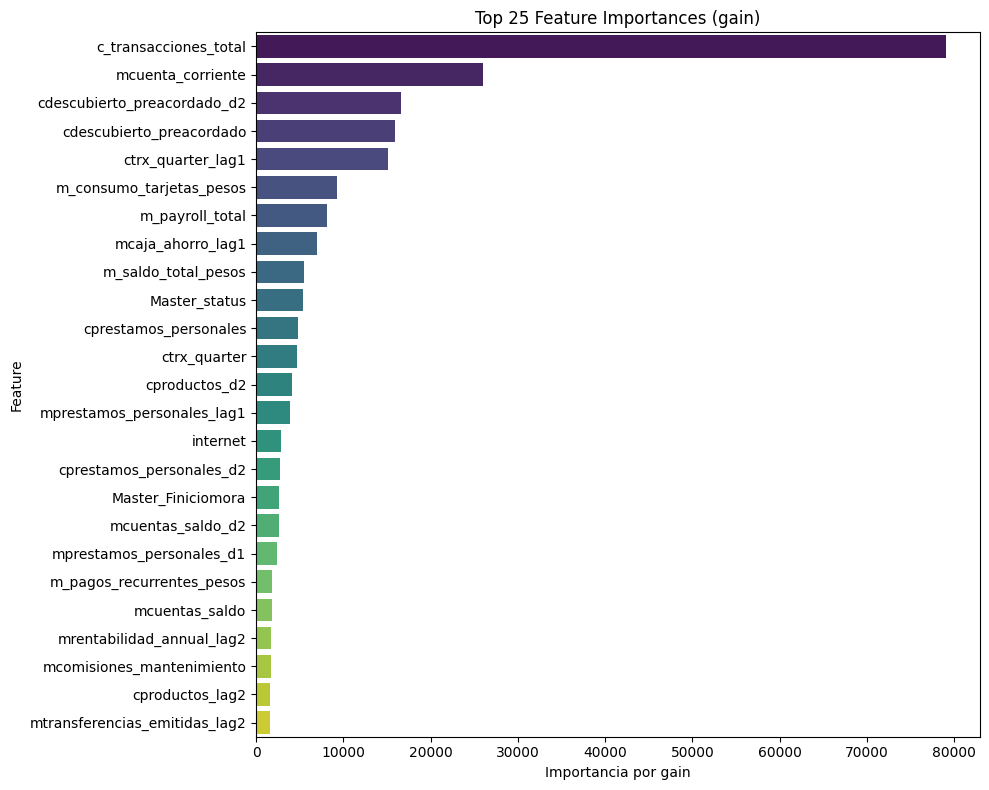

In [13]:
# =========================
# 8) Feature importance del modelo LightGBM
# =========================

feature_importance_gain = model.feature_importance(importance_type="gain")
feature_importance_split = model.feature_importance(importance_type="split")

importance_df = (
    pd.DataFrame(
        {
            "feature": feature_cols,
            "gain": feature_importance_gain,
            "split": feature_importance_split,
        }
    )
    .sort_values("gain", ascending=False)
)

print("Top 10 features por gain")
print(importance_df.head(10))

plt.figure(figsize=(10, 8))
sns.barplot(
    data=importance_df.head(25),
    x="gain",
    y="feature",
    palette="viridis",
)
plt.title("Top 25 Feature Importances (gain)")
plt.xlabel("Importancia por gain")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [15]:
%%time
# =========================
# 9) Predicciones binarias finales y archivo submit
# =========================

# predictions_per_seed viene del semillero (lista de arrays, uno por seed)
predictions_matrix = np.vstack(predictions_per_seed)      # shape: (ksemillerio, n_clientes)
final_predictions = np.mean(predictions_matrix, axis=0)   # promedio por cliente

# Ordenar clientes según probabilidad promedio
clientes_ordenados = np.argsort(final_predictions)[::-1]

n_clientes_objetivo = 11000
predicciones_binarias = np.zeros(len(final_predictions), dtype=int)
predicciones_binarias[clientes_ordenados[:n_clientes_objetivo]] = 1

id_apply = apply_df["numero_de_cliente"].to_numpy()
submit_df = pd.DataFrame(
    {
        "numero_de_cliente": id_apply[clientes_ordenados],
        "Predicted": predicciones_binarias[clientes_ordenados],
    }
)

submit_path = BASE_DIR / "CAVIGLIA_202109_SEMILLERO_50_SEEDS.csv"
submit_path.parent.mkdir(parents=True, exist_ok=True)
submit_df.to_csv(submit_path, index=False)

print("=== Submit APPLY listo ===")
print(f"Archivo: {submit_path}")
print(f"Clientes positivos: {predicciones_binarias.sum()} de {len(predicciones_binarias)}")


=== Submit APPLY listo ===
Archivo: /home/nicocaviglia031/dmeyf2025/Competencia 3 Entrega Final/dmeyf2025/CAVIGLIA_202109_SEMILLERO_50_SEEDS.csv
Clientes positivos: 11000 de 165093
CPU times: user 207 ms, sys: 14 ms, total: 221 ms
Wall time: 1.02 s


In [16]:
# Filtrar los clientes con Predicted == 1
df_filtered_ensemble = submit_df[submit_df["Predicted"] == 1][["numero_de_cliente"]]
# Guardar CSV sin encabezados ni índice
df_filtered_ensemble.to_csv("Pikachu_FORMATO_ENTREGA_CAVIGLIA_202109_50_SEMILLAS.csv", index=False, header=False)